# Geometrical phantom reconstruction baseline

This notebook will load in all geometrical phantoms in the directory `Pixel_phantom\phantom_arrays` and produce a sinogram, and reconstruct the phantom images again using SIRT and FBP algorithms. Run all cells in order to see all the reconstructed images, with their respective original, and sinogram image. It may take a while to reconstruct all phantoms

In [1]:
import astra
import matplotlib.pyplot as plt
import numpy as np
import os
from ReconstructionAlgorithms import SIRT, FBP
from Sinograms import sinogram
astra.test() # if everything works properly you should see information about your GPU and CUDA capability

No GPU support available
ASTRA Toolbox v2.4.1
Testing basic CPU 2D functionality... Ok


## Load in phantom data

In [ ]:
path = "Pixel_phantom\phantom_arrays"

phantoms = {}
for fname in os.listdir(path):
    if fname.endswith('.npz'):
        phantom_path = os.path.join(path, fname)
        data = np.load(phantom_path)
        phantoms[fname.replace('.npz', '')] = data[list(data.keys())[0]]

## Plotting function

In [3]:
def plot(phantom, sinogram_img, sirt_reconstruction,  fbp_reconstruction, figsize=(10, 10)):
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
    ax[0, 0].imshow(phantom, cmap='gray')
    ax[0, 1].imshow(sinogram_img, cmap='gray')
    ax[1, 0].imshow(sirt_reconstruction, cmap='gray')
    ax[1, 1].imshow(fbp_reconstruction, cmap='gray')

    ax[0, 0].set_title("Original phantom")
    ax[0, 1].set_title("Sinogram")
    ax[1, 0].set_title("Sirt reconstruction")
    ax[1, 1].set_title("FBP reconstruction")


    ax[0, 0].axis('off')
    ax[0, 1].axis('off')
    ax[1, 0].axis('off')
    ax[1, 1].axis('off')

    fig.tight_layout()

    plt.show()

## Evaluation function

uses the Root Mean Squared (RMS) error to evaluated the reconstructed phantom images

In [4]:
def rms(original, reconstruction):
    return np.sqrt(np.mean((original - reconstruction) ** 2))

## Actual simulation loop

This loop creates the sinogram using the `sinogram` function from the phantoms numpy arrays. These sinograms are passed into both the `FBP` and `SIRT` function to reconstruct the phantom image again. This is done in a loop over all possible pixelbased phantoms. Each seperate phantom reconstruction will be shown, with at the upper left corner the original phantom, the upper right corner the sinogram, the lower left corner the SIRT reconstruction, and at the lower right corner the FBP reconstruction. The respective RMS are displayed above the images.

granular_phantom_2_grayvaluess — SIRT RMS: 32.5750 | FBP RMS: 33.9924


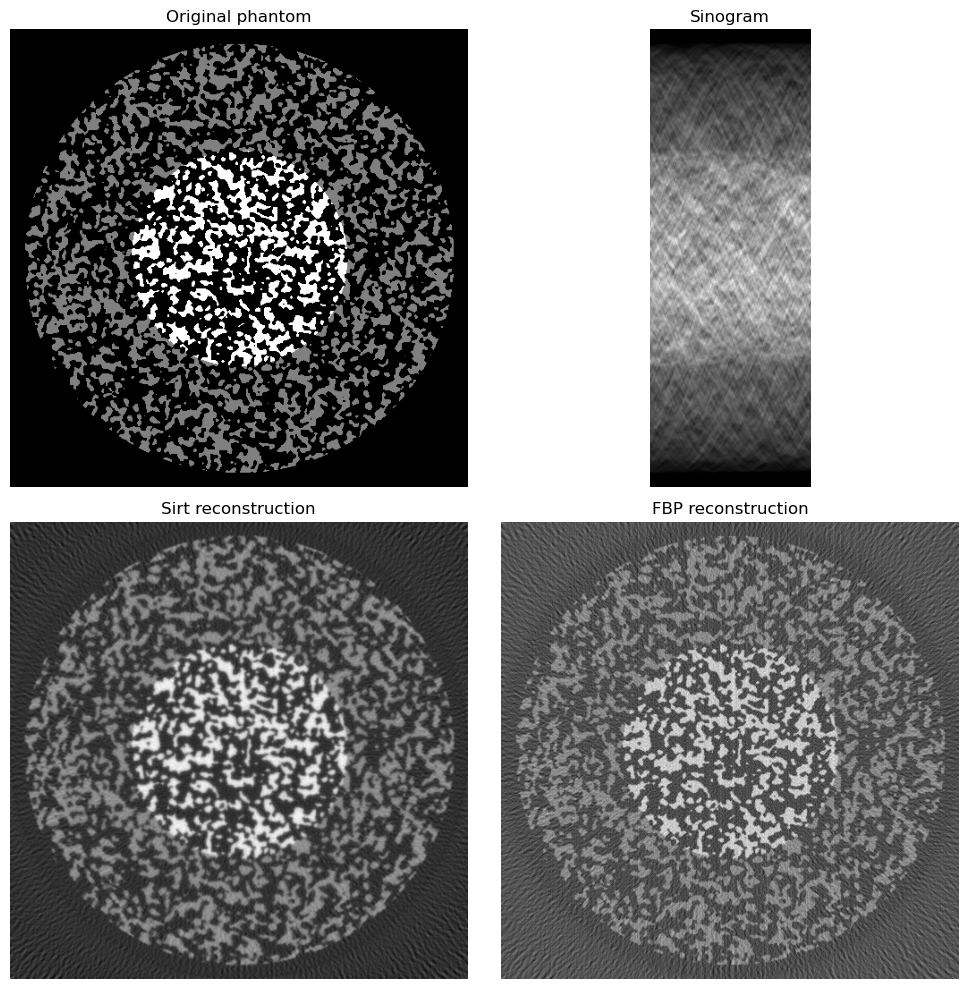

granular_phantom_multiple_grayvalues — SIRT RMS: 30.3284 | FBP RMS: 31.4032


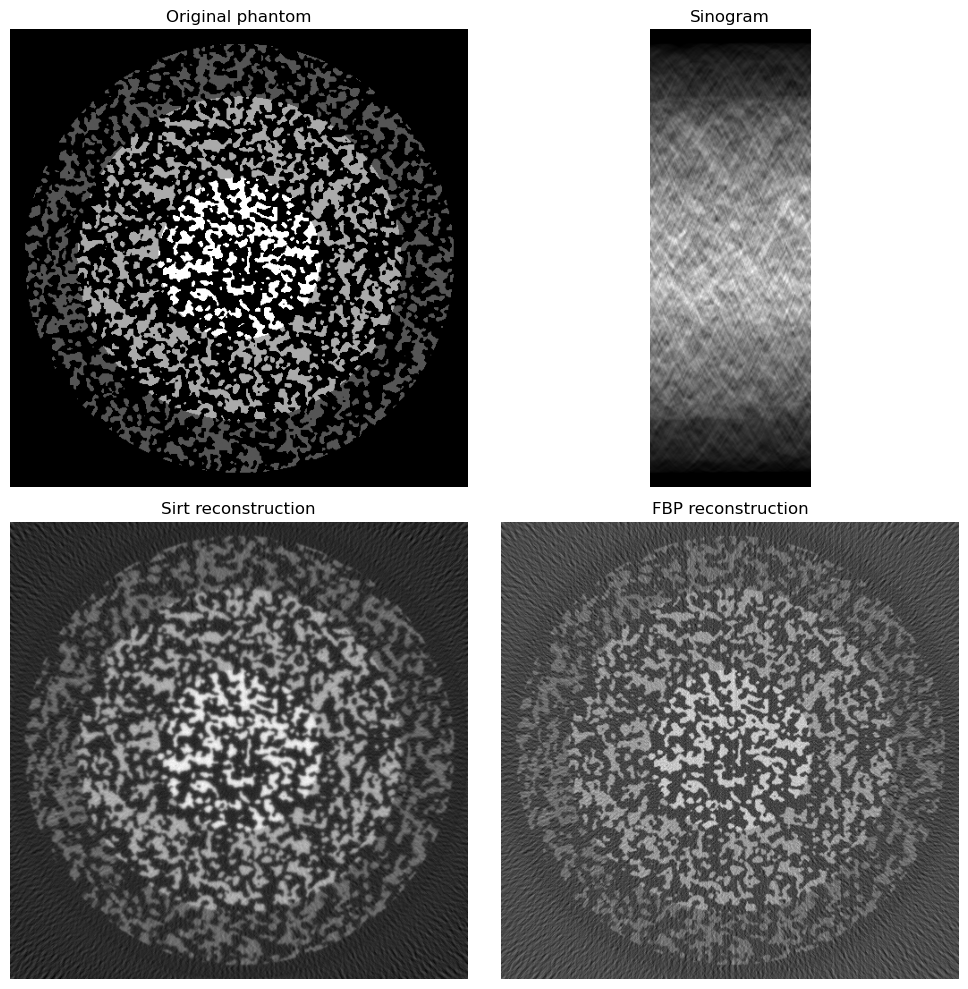

granular_phantom_single_grayvalues — SIRT RMS: 48.9353 | FBP RMS: 51.8403


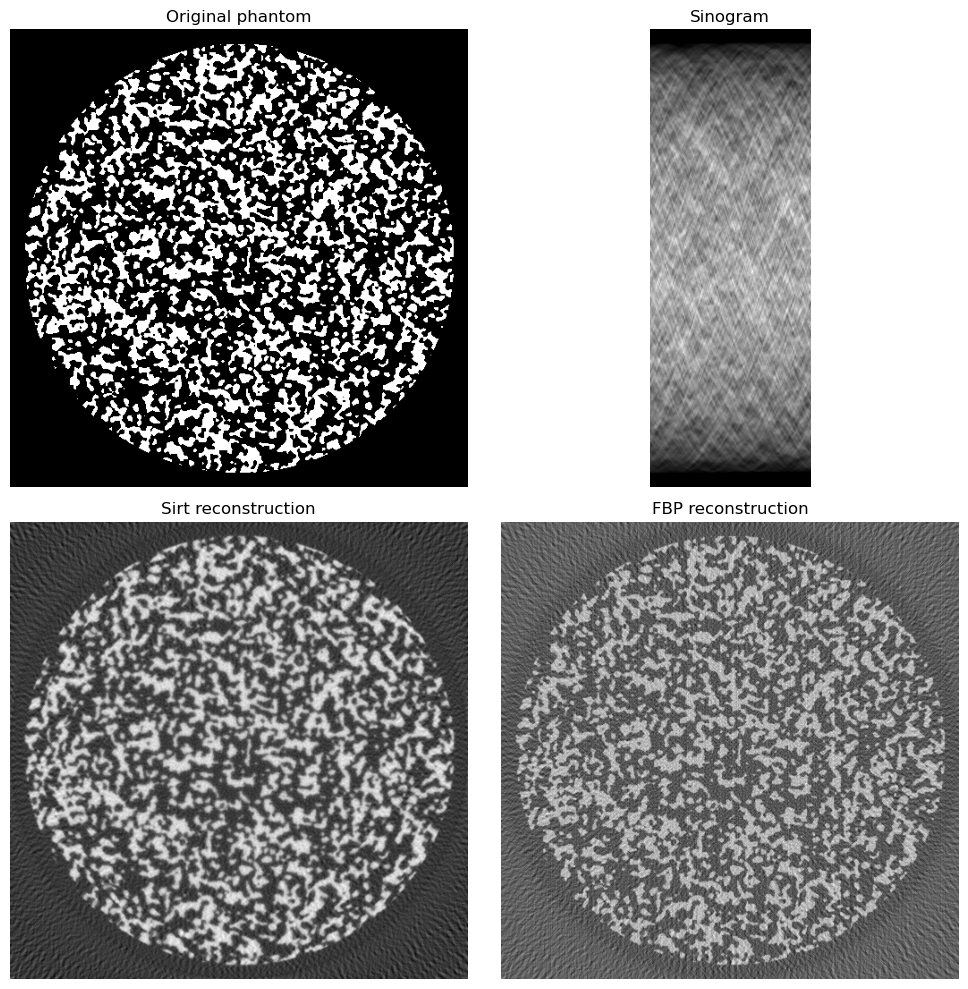

multiple_random_shapes_different_gray — SIRT RMS: 8.8019 | FBP RMS: 13.0986


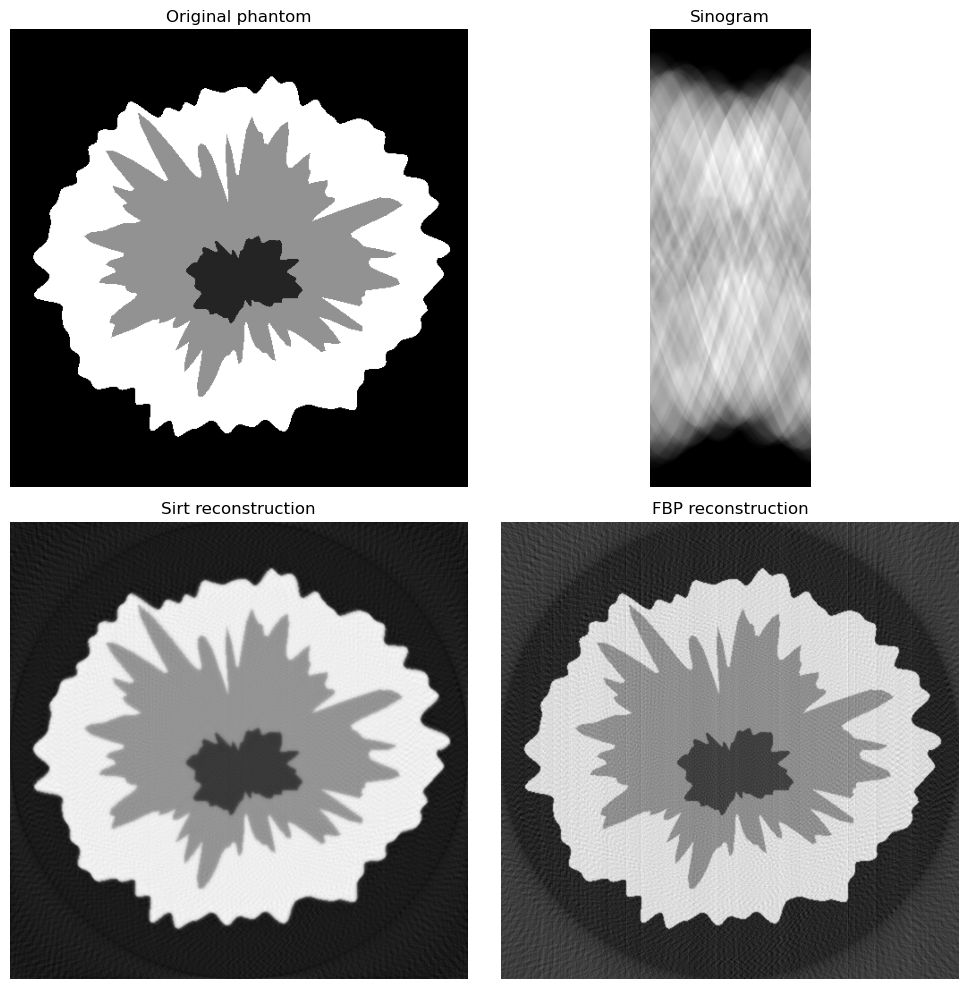

Porouse_with_different_density — SIRT RMS: 22.6983 | FBP RMS: 48.8111


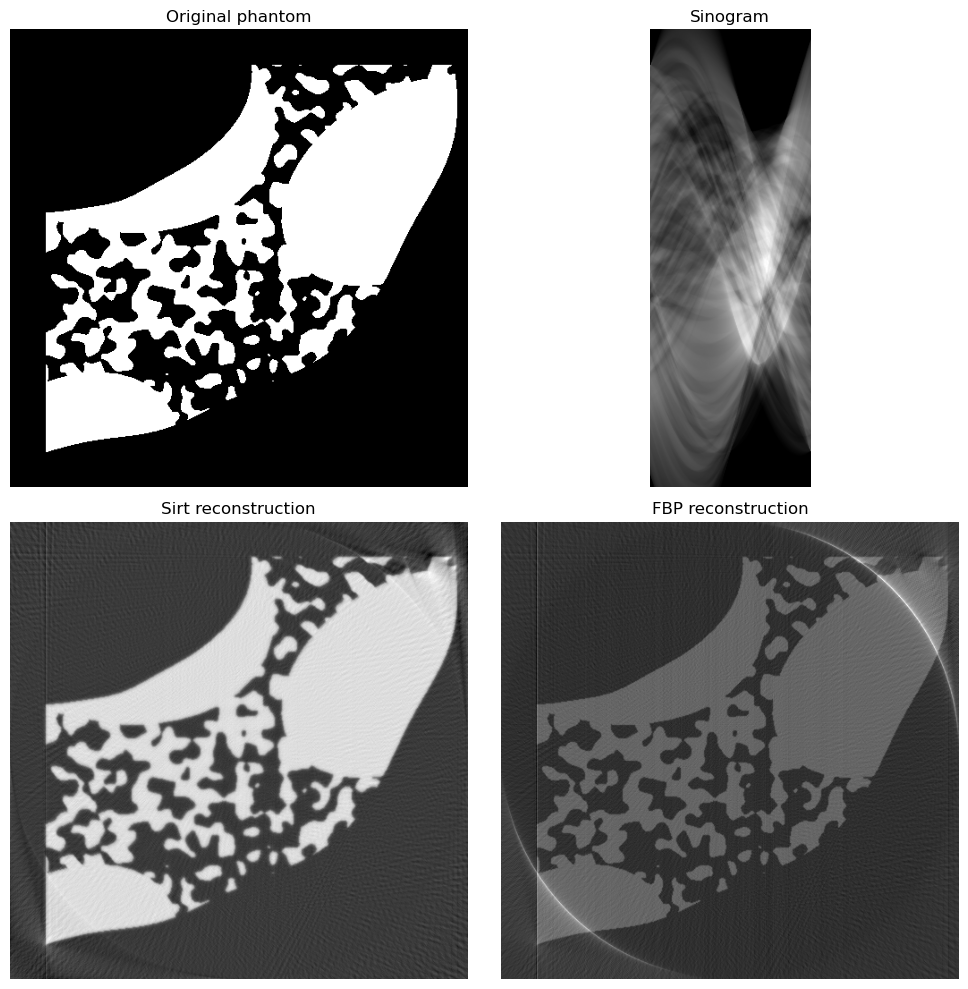

Random_shape — SIRT RMS: 9.7367 | FBP RMS: 10.9592


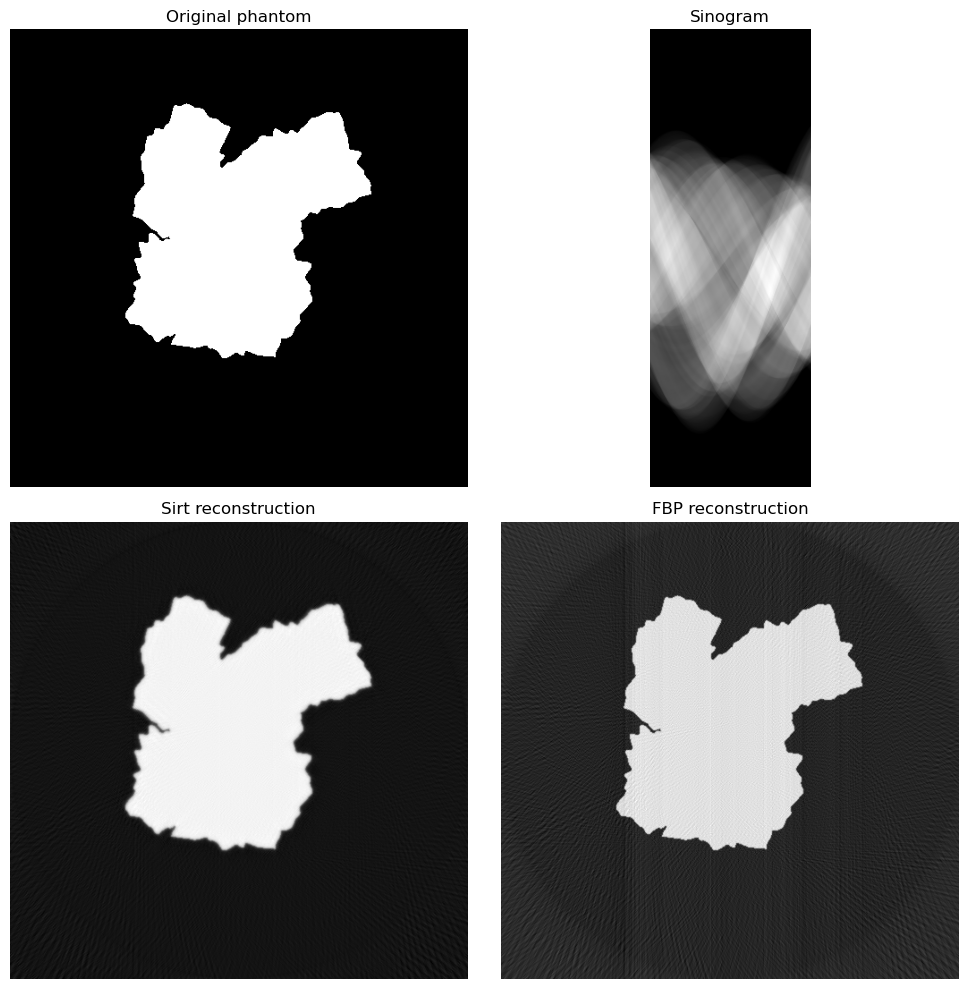

Random_shape_2_gray — SIRT RMS: 9.8092 | FBP RMS: 10.9678


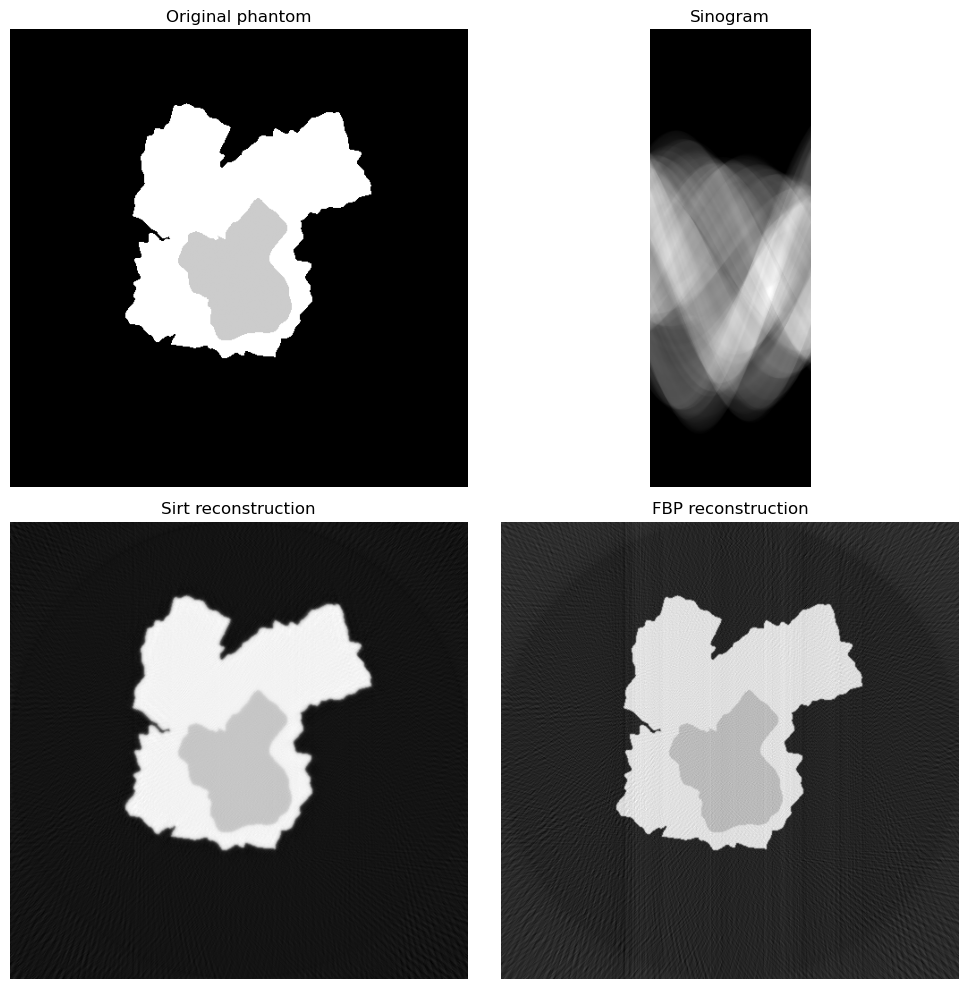

Random_shape_multipl_gray — SIRT RMS: 10.3596 | FBP RMS: 11.7292


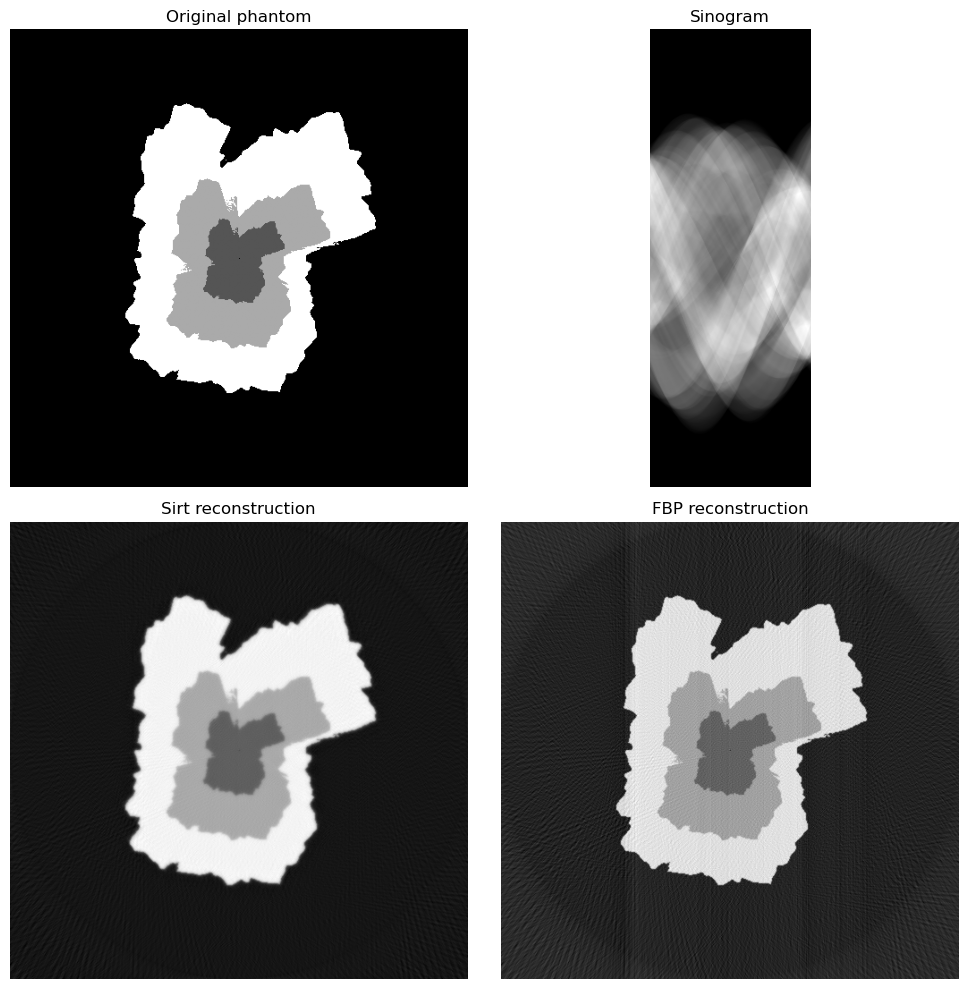

Random_structures_Holes — SIRT RMS: 19.8811 | FBP RMS: 40.6378


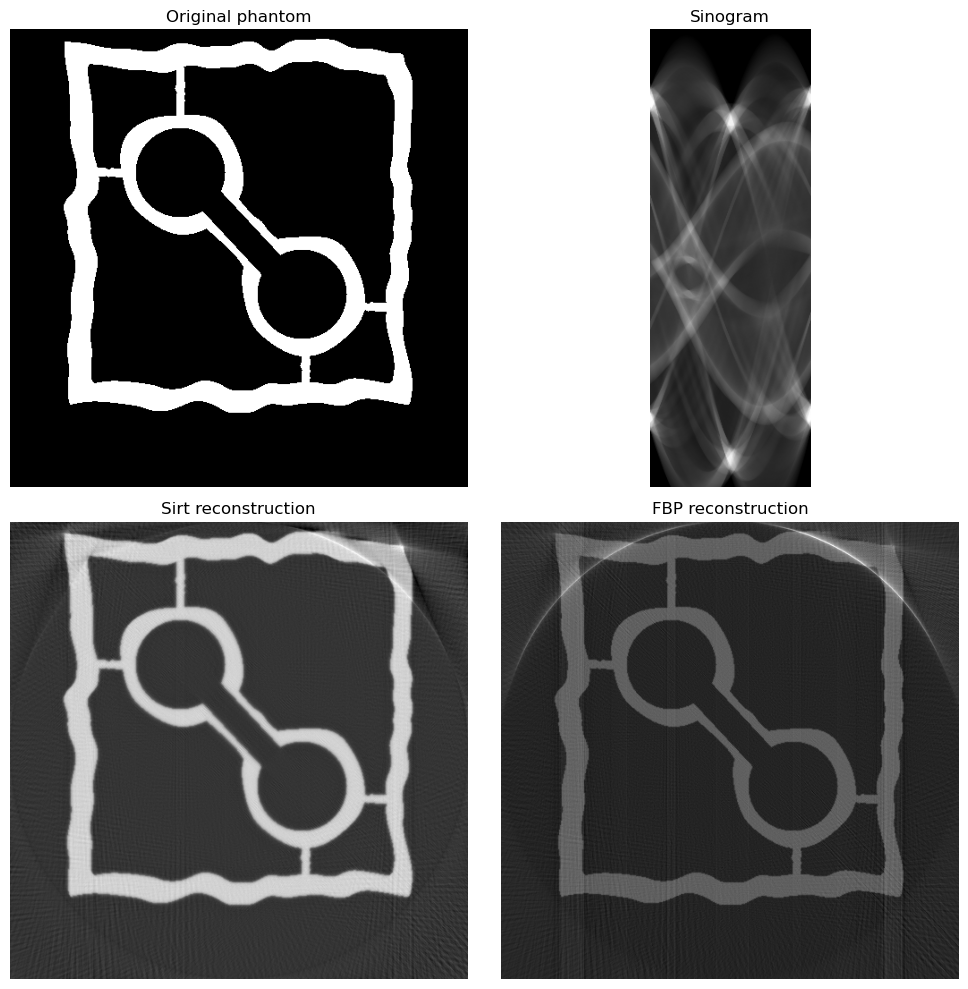

In [ ]:
# Optimal projection settings
n_projections = 180
n_detectors = 512
angles = np.linspace(0, np.pi, n_projections)
detector_spacing = 1

results = {}
for name, img in phantoms.items():
    
    proj_id, sino_id, sino_data, vol_geom, proj_geom = sinogram(
        phantom=img,
        n_projections=n_projections,
        n_detectors=n_detectors,
        angles=angles,
        detector_spacing=detector_spacing
    )
    _, fbp_res = FBP(vol_geom, sino_id, proj_geom, sino_data, use_gpu=False)
    _, sirt_res = SIRT(vol_geom=vol_geom,  proj_geom=proj_geom, sinogram=sino_data, projector_id=proj_id, vol_data=0, iters=200, use_gpu=False)
    rms_sirt = rms(img, sirt_res)
    rms_fbp = rms(img, fbp_res)
    print(f"{name} — SIRT RMS: {rms_sirt:.4f} | FBP RMS: {rms_fbp:.4f}")

    plot(
        phantom=img,
        sinogram_img=sino_data.T,
        sirt_reconstruction=sirt_res,
        fbp_reconstruction=fbp_res
    )